In [2]:
# load some library
import numpy as np
import sys
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.dates import DateFormatter
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import matplotlib.dates as mdates
from calendar import Calendar
c = Calendar()
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import xarray as xr
#from google.colab.data_table import DataTable
#DataTable.max_columns = 40
import scikit_posthocs as sp
import math
import matplotlib.pyplot as plt
import sys
#import msfunctions

sys.path.append(os.path.expanduser('../../'))
from utils.functions import normalcy, pull_data, kruskal_drops
from utils.visuals import batch_bar, batch_bar_overlay, intertidal_box_plot, batch_box_plot

## Call csv file
* save master sheet as the current date in 'mmddyyy.csv' format
* make a new column called 'date' and takes my'date of collection' column and makes it a datetime format

In [3]:
start_date = '2022-07-01T12:00:00'
end_date = '2023-04-06T12:00:00'

data_path = 'C:/Users/jespi/sfsu-masters/sfsu-masters-anthopleura-sola-1/biotic_data/simplified_master_data.csv'
a_sola_data = pd.read_csv(data_path)
a_sola_data['date_time'] = pd.to_datetime(a_sola_data['date_of_collection'])
a_sola_data = a_sola_data[(a_sola_data['date_time'] > start_date) & (a_sola_data['date_time'] <= end_date)]
a_sola_data['doy'] = a_sola_data['date_time'].dt.strftime('%j')
a_sola_data['doy'] = a_sola_data['doy'].astype(str).astype(int)

## Process Biotic Data
Within the pulled 'master dataset' are data retrieved while collection and laboratory methods were being developed (samples within collection groups 1 through 3). While included in the master dataset, they are omitted from the data analysis.


### Alga Density
Aside from collection groups 1-3 being removed from the analysis, three extreme outliers within the algal density metric were also subset out. 

In [4]:
# Filter for non-null 'collection_group'
a_sola_algae_data = a_sola_data[a_sola_data['collection_group'].notnull()]

# Exclude specific 'collection_group' values and filter on 'num_cells_per_ug_protein'
a_sola_algae_data = a_sola_algae_data[
    (~a_sola_algae_data['collection_group'].isin([1.0, 2.0, 3.0])) &
    (a_sola_algae_data['num_cells_per_ug_protein'].notnull()) &
    (a_sola_algae_data['num_cells_per_ug_protein'] < 3000)
]
a_sola_algae_data = a_sola_algae_data.drop(columns='ng_chlorophyll_per_ug_protein')

# Extract 'doy' column and count the rows
algae_doy = a_sola_algae_data['doy']
num_rows = len(a_sola_algae_data)

print(num_rows)

380


### Chlorophyll
Aside from collection groups 1-3 being removed from the analysis, ......

Note - Prepared chlorophyll concentration samples from collection #7 (collection dates Oct. 11/12 2022) were contaminated and are missing from the dataset.

In [5]:
# Filter for non-null 'collection_group'
a_sola_chlorophyll_data = a_sola_data[a_sola_data['collection_group'].notnull()]

# Exclude specific 'collection_group' values and filter on required columns
a_sola_chlorophyll_data = a_sola_chlorophyll_data[
    (~a_sola_chlorophyll_data['collection_group'].isin([1.0, 2.0, 3.0])) &
    (a_sola_chlorophyll_data['num_cells_per_ug_protein'].notnull()) &
    (a_sola_chlorophyll_data['ng_chlorophyll_per_ug_protein'].notnull()) &
    (a_sola_chlorophyll_data['num_cells_per_ug_protein'] < 3000)
]

# Extract 'doy' column and count the rows
chl_doy = a_sola_chlorophyll_data['doy']
num_rows = len(a_sola_chlorophyll_data)

print(num_rows)


330


# Visualize each dataset shape via histogram

[Text(0.5, 1.0, 'ng Chlorophyll per Animal Protein')]

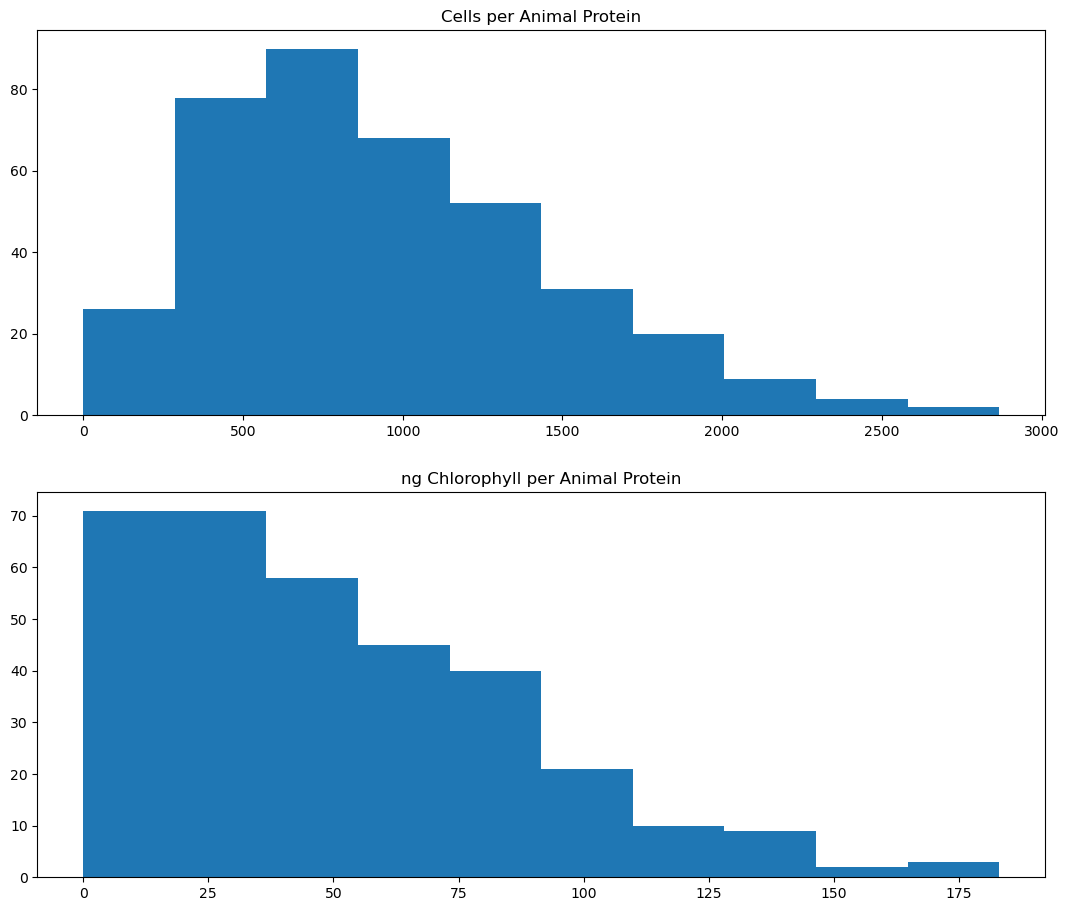

In [6]:
fig, (ax1, ax2)  = plt.subplots(2, 1, sharey=False, figsize=(13,11))

ax1.hist(a_sola_algae_data.num_cells_per_ug_protein)
ax1.set(title ='Cells per Animal Protein')

ax2.hist(a_sola_chlorophyll_data.ng_chlorophyll_per_ug_protein)
ax2.set(title ='ng Chlorophyll per Animal Protein')

### **Shapiro-Wilk test** 
Check if data is normally distributed

p-value interpretation: 
* p > 0.05 means we fail to reject the null hypothesis, suggesting data is likely normal
* p ≤ 0.05 means we reject the null, indicating data significantly deviates from normality, making it non-normal.

Our interpretation of algal density and chlorophyll concentration datasets:
Both datasets p-values are significantly below the 0.05 threshold and their skewed histograms suggest both dependent datasets are **non-normal**

In [7]:
print('Testing normalcy of algal density data:')
normalcy(a_sola_algae_data, 'num_cells_per_ug_protein')
print('')
print('Testing normalcy of chlorophyll concentration data:')
normalcy(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein')

Testing normalcy of algal density data:
ShapiroResult(statistic=0.9552969336509705, pvalue=2.4637145656924986e-09)

Testing normalcy of chlorophyll concentration data:
ShapiroResult(statistic=0.930269181728363, pvalue=2.6439853778592592e-11)


# Bar graphs
For algal density and chlorophyll concentration respectively:
* group data by collection group and intertidal zone
* plot mean, SEM error bars
* indicate sample size for each intertidal zone

Algal Density

Plot saved to figures/pre_annotated_figures/algal_tidal_bars_no_title.png


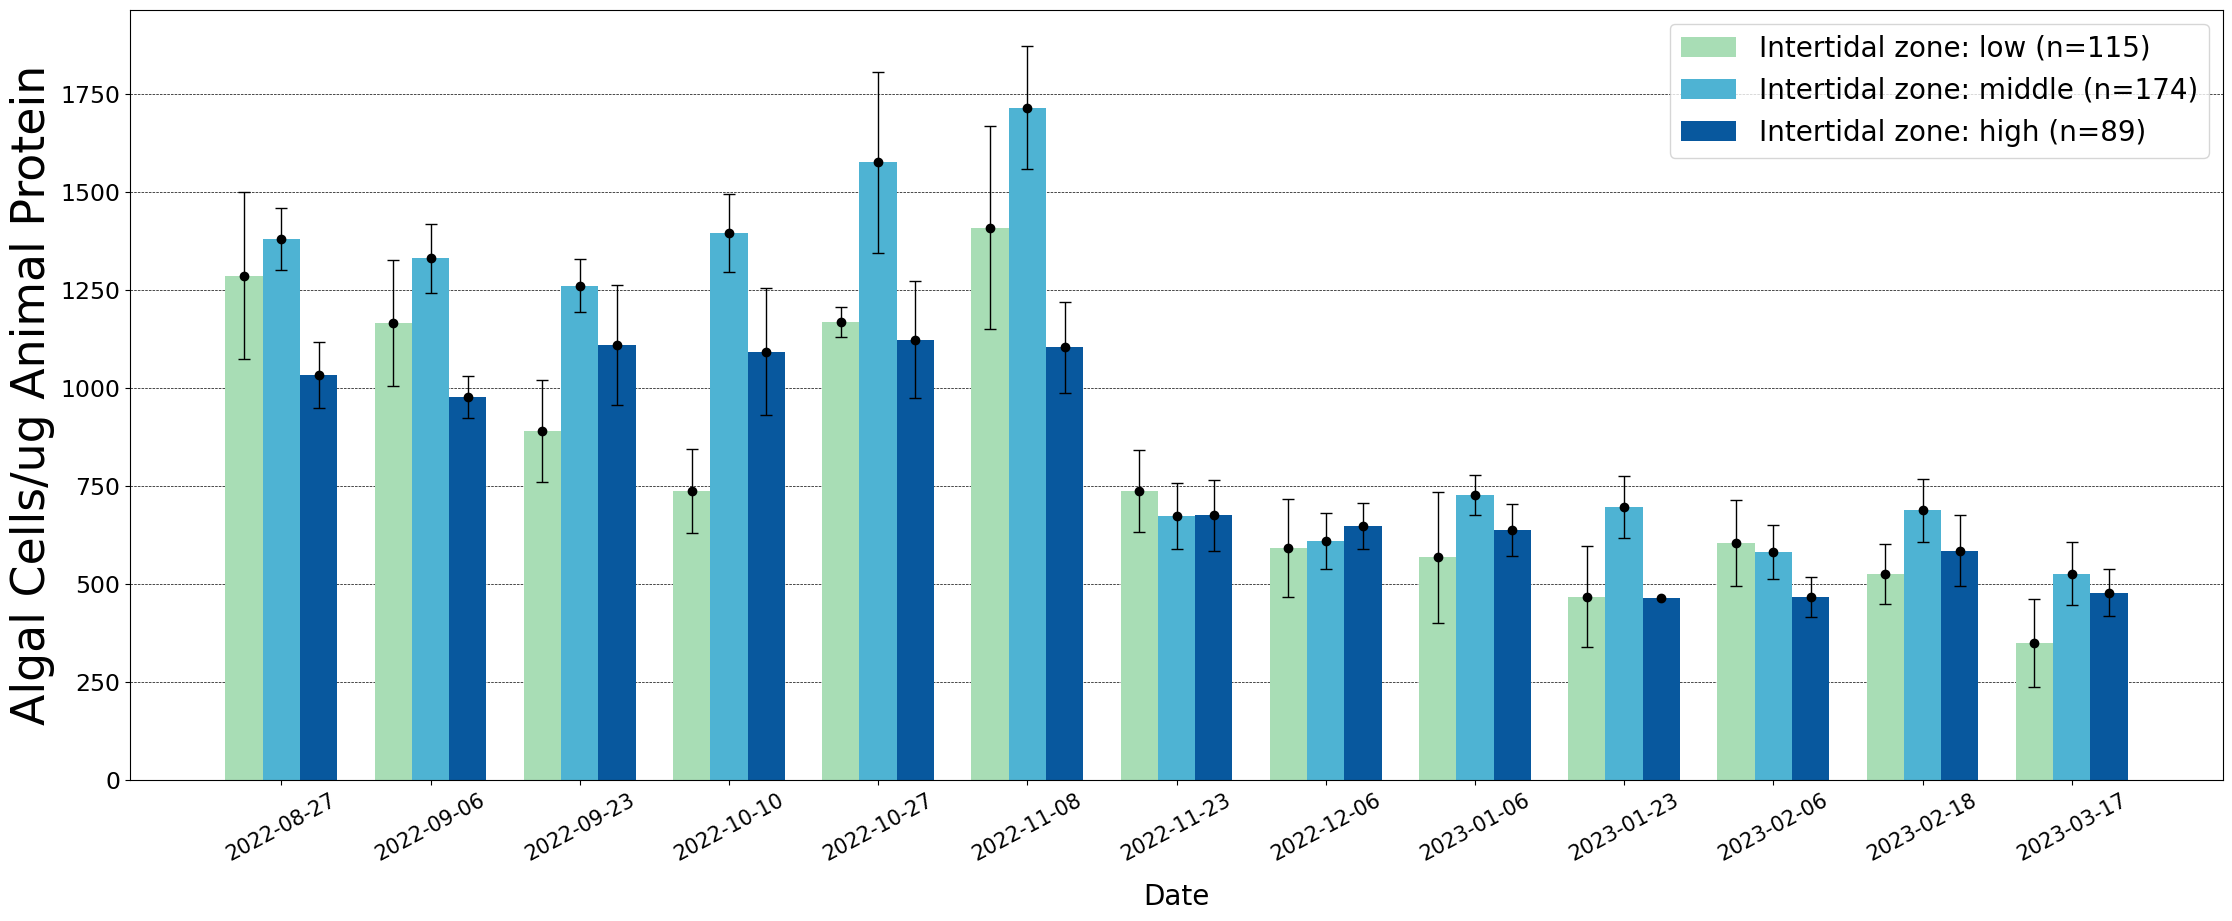

In [8]:
batch_bar_overlay(a_sola_algae_data, 'num_cells_per_ug_protein', save_path='figures/pre_annotated_figures/algal_tidal_bars_no_title.png', colors=['#a8ddb5', '#4eb3d3', '#08589e'])

Chlorophyll Concentration

No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
No data found for group 7
No data found for variable ng_chlorophyll_per_ug_protein
Plot saved to figures/pre_annotated_figures/chlorophyll_tidal_bars_no_title.png


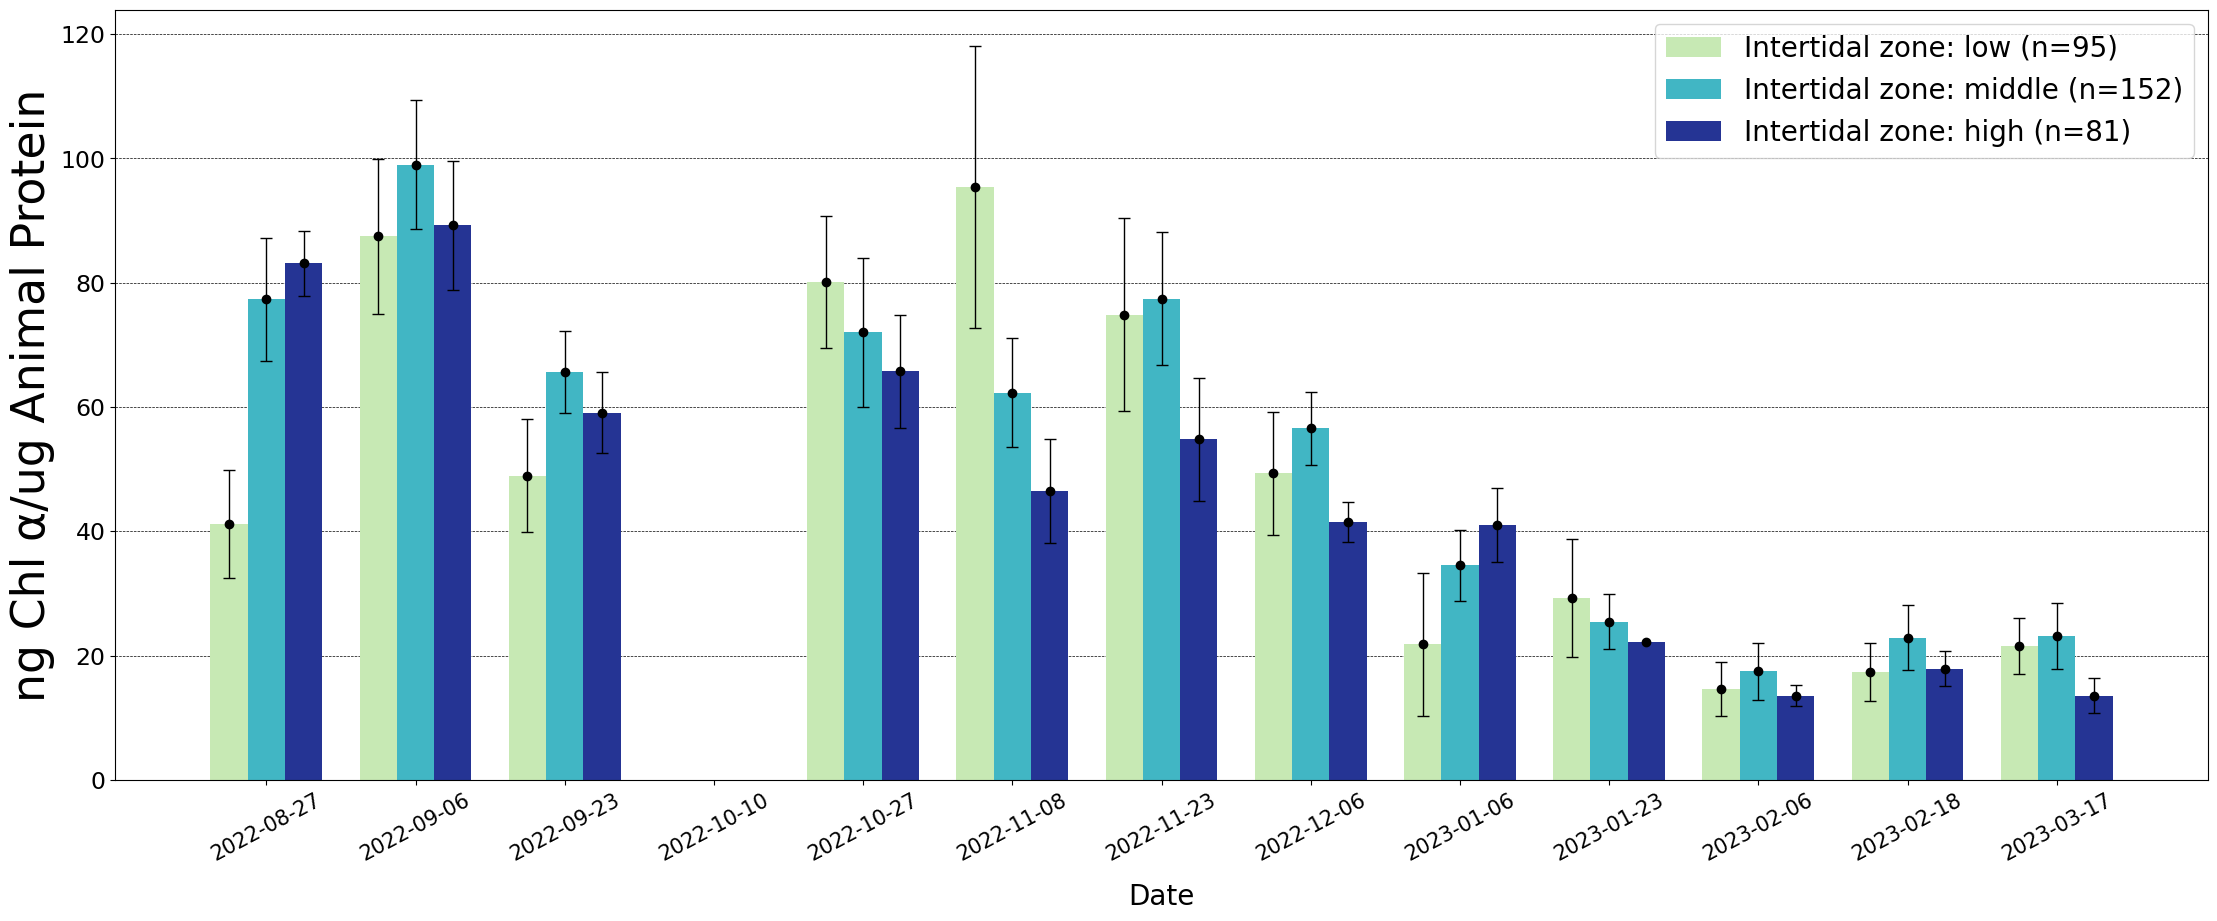

In [9]:
batch_bar_overlay(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein', save_path='figures/pre_annotated_figures/chlorophyll_tidal_bars_no_title.png', colors=['#c7e9b4', '#41b6c4', '#253494'])

## Box Plots
Generate box plot figures summarizing data by collection date across all tidal zones over time

Algal Density

Plot saved to plots/algae_box_no_title.png


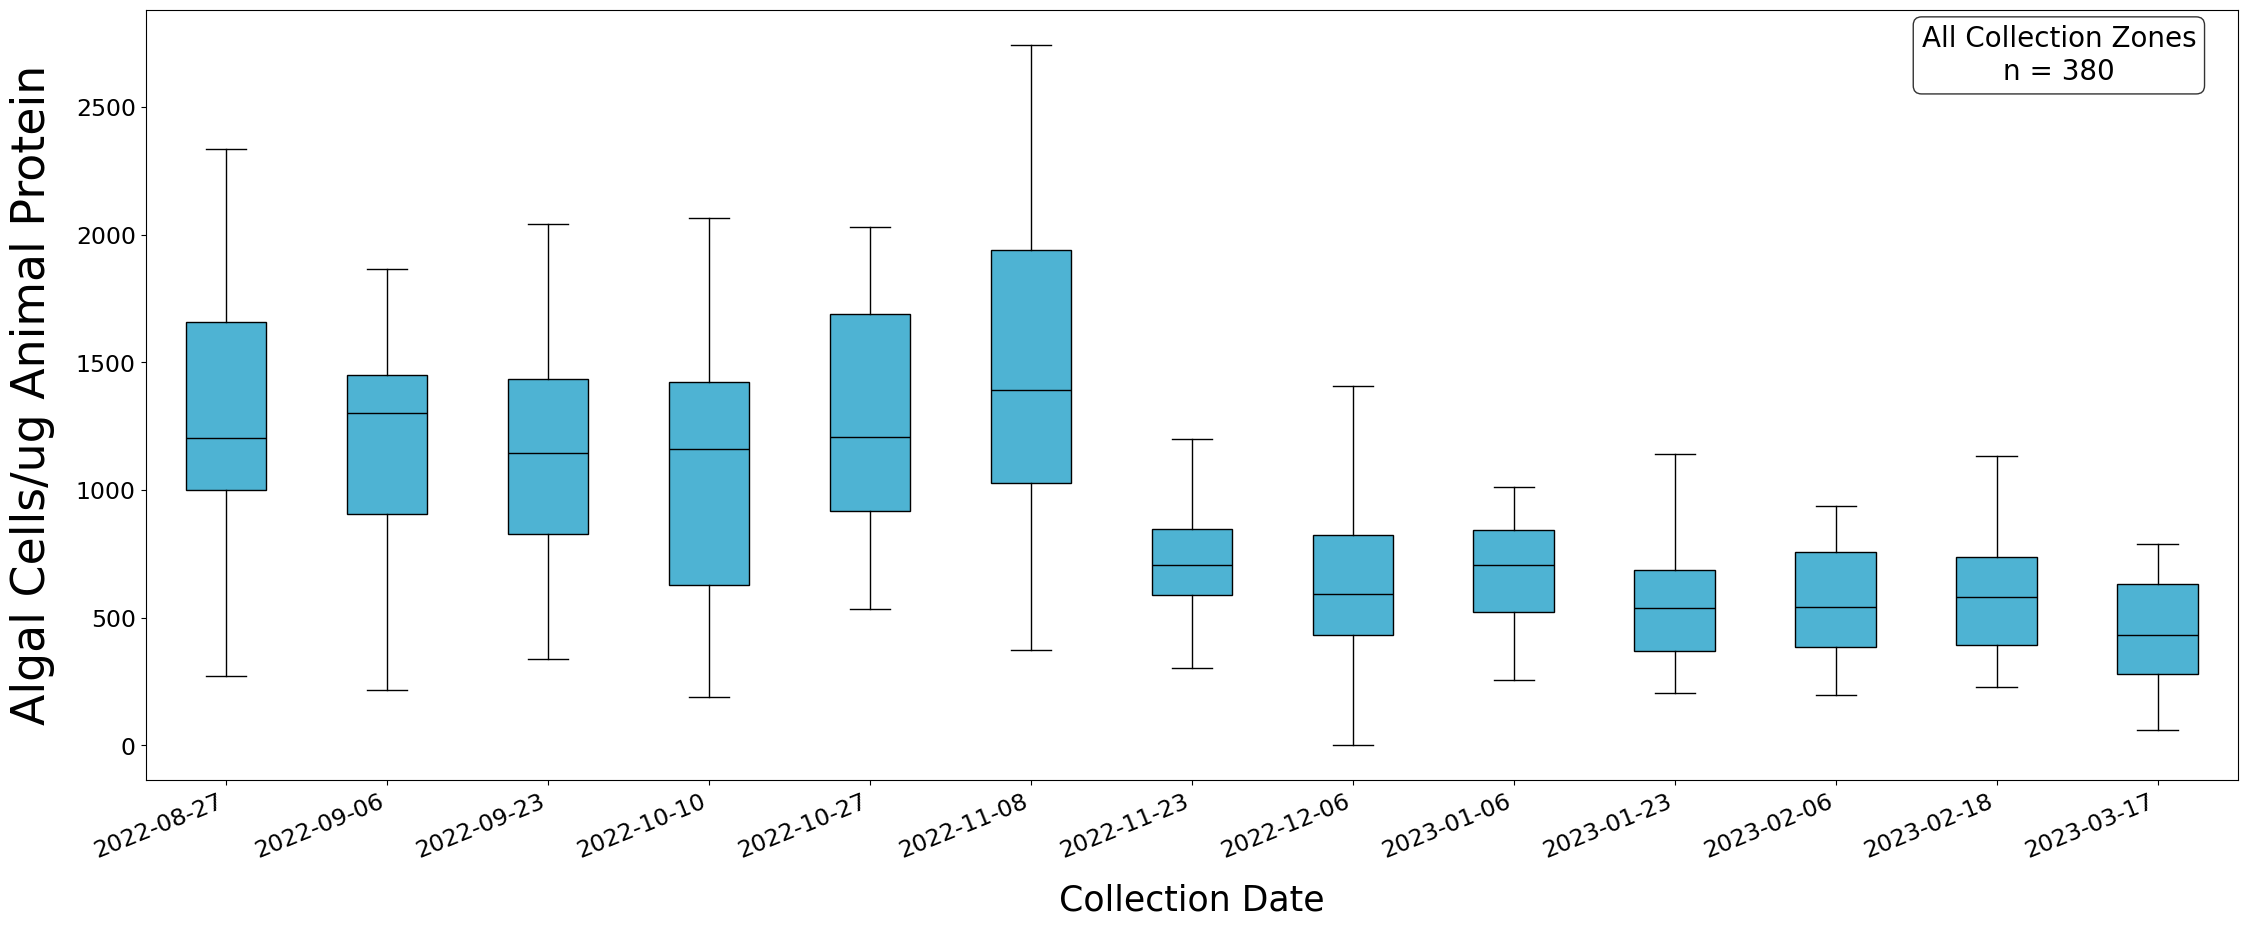

In [10]:
batch_box_plot(a_sola_algae_data, 'num_cells_per_ug_protein', 'Algal Cells/ug Animal Protein', 
               zone='', save_path='plots/algae_box_no_title', 
               box_colors='#4eb3d3') 

Chlorophyll Concentration

No data found for group 7
No data found for batch size 7, skipping...
Plot saved to plots/chl_box_no_title.png


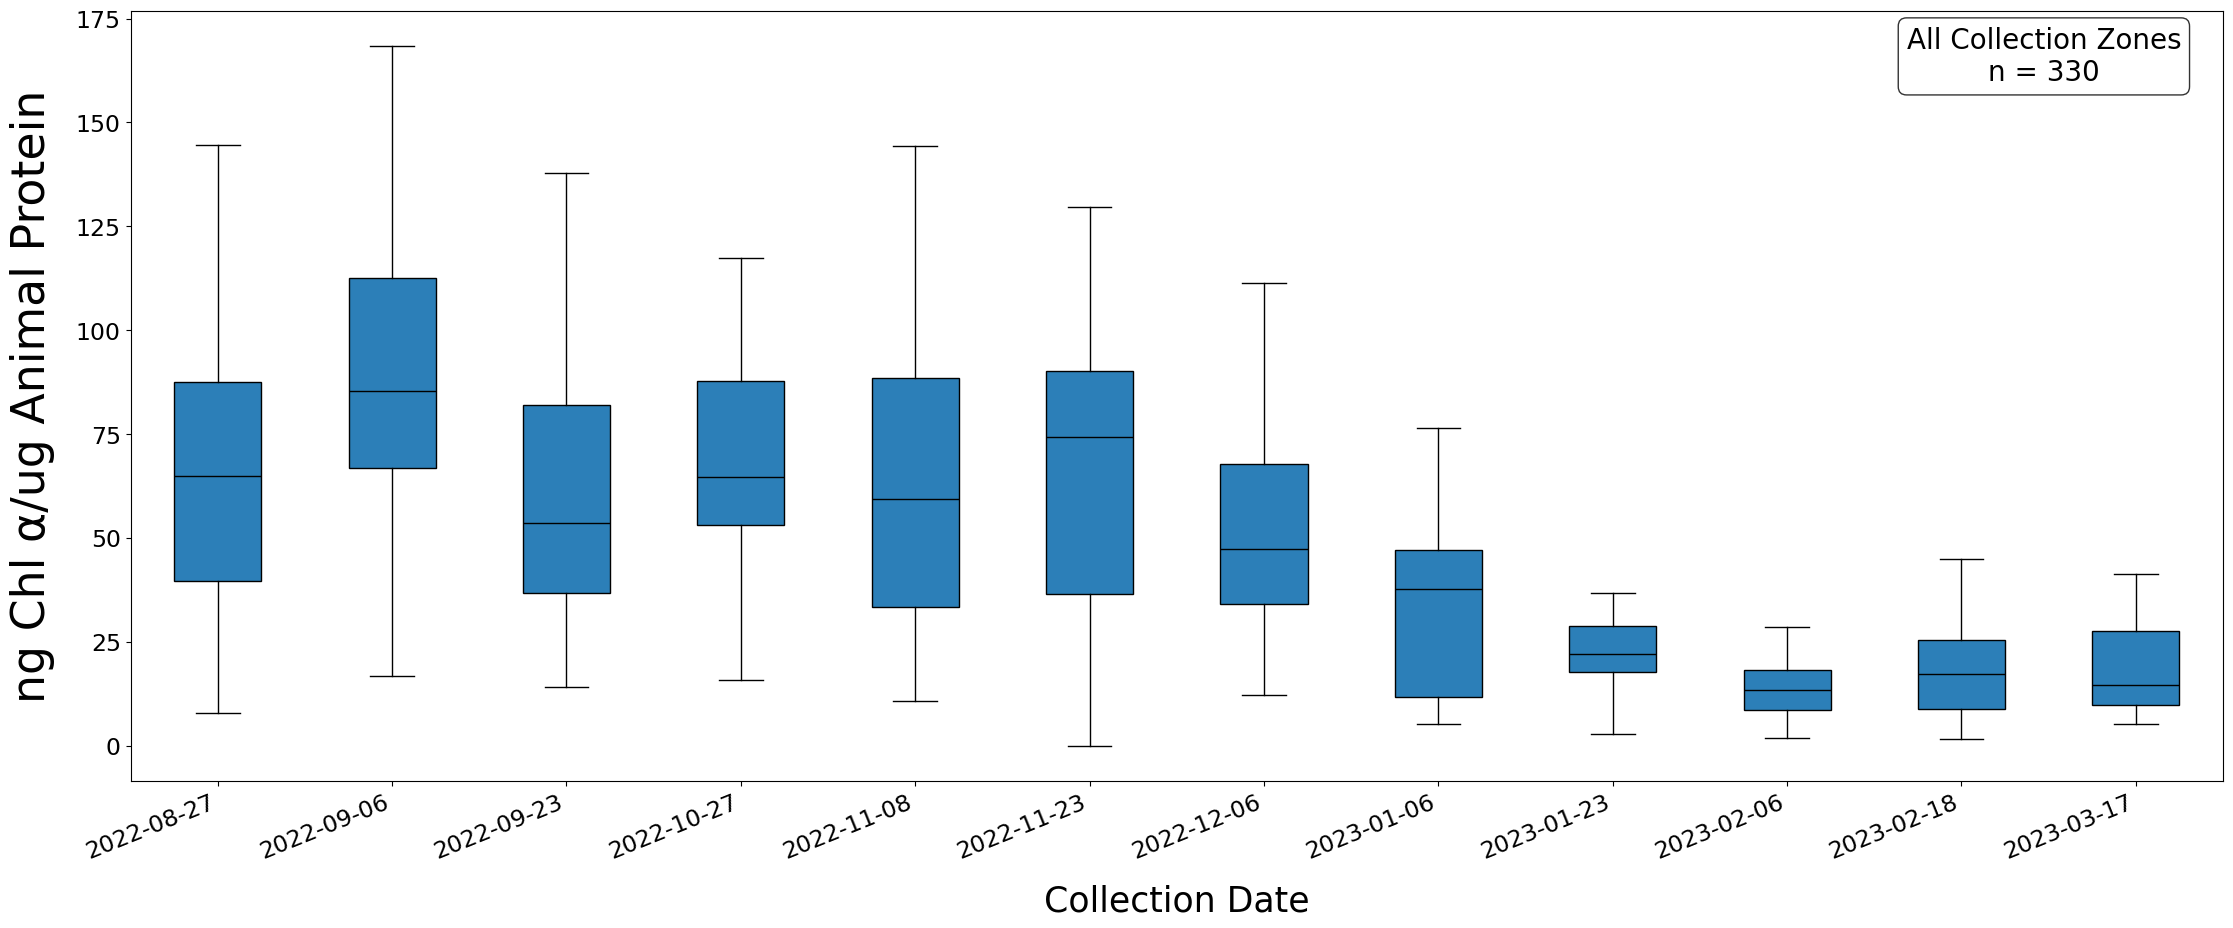

In [11]:
batch_box_plot(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein', 'ng Chl α/ug Animal Protein', 
               zone='', save_path='plots/chl_box_no_title',
               box_colors='#2c7fb8') 

## Kruskal-Wallis test pre vs post drop observed in the bar graph
* can use individual tidal heights or all

In [12]:
kruskal_drops(a_sola_algae_data, 'num_cells_per_ug_protein', 'all')

Testing pre ShapiroResult(statistic=0.9885910749435425, pvalue=0.10484080761671066) vs post ShapiroResult(statistic=0.9921711087226868, pvalue=0.4551841616630554) drop normalcy
Testing all intertidal zones before vs after drop: KruskalResult(statistic=145.00073719598595, pvalue=2.1468405193222063e-33)


In [13]:
kruskal_drops(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein', 'all')

Testing pre ShapiroResult(statistic=0.9643855094909668, pvalue=0.0005476570222526789) vs post ShapiroResult(statistic=0.8705012202262878, pvalue=3.324244005065147e-11) drop normalcy
Testing all intertidal zones before vs after drop: KruskalResult(statistic=86.93546383340731, pvalue=1.1212074601772981e-20)


## Testing statistical significance between intertidal zones

In [14]:
data = [a_sola_algae_data[a_sola_algae_data['intertidal_zone']=="low"]['num_cells_per_ug_protein'],
        a_sola_algae_data[a_sola_algae_data['intertidal_zone']=="medium"]['num_cells_per_ug_protein'],
        a_sola_algae_data[a_sola_algae_data['intertidal_zone']=="high"]['num_cells_per_ug_protein']]

# using the posthoc_dunn() function
p_values= sp.posthoc_dunn(data, p_adjust = 'holm')

print(p_values)

          1         3
1  1.000000  0.260505
3  0.260505  1.000000


In [15]:
data = [a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="low"]['ng_chlorophyll_per_ug_protein'],
        a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="medium"]['ng_chlorophyll_per_ug_protein'],
        a_sola_chlorophyll_data[a_sola_chlorophyll_data['intertidal_zone']=="high"]['ng_chlorophyll_per_ug_protein']]

# using the posthoc_dunn() function
p_values= sp.posthoc_dunn(data, p_adjust = 'holm')

print(p_values)

          1         3
1  1.000000  0.808848
3  0.808848  1.000000


# Intertidal zone box plot
Summary box plot(s) that visualize variable mean and SEM grouped for each tidal zone and across time

Plot saved to plots/algae_intertidal_box_plot.png


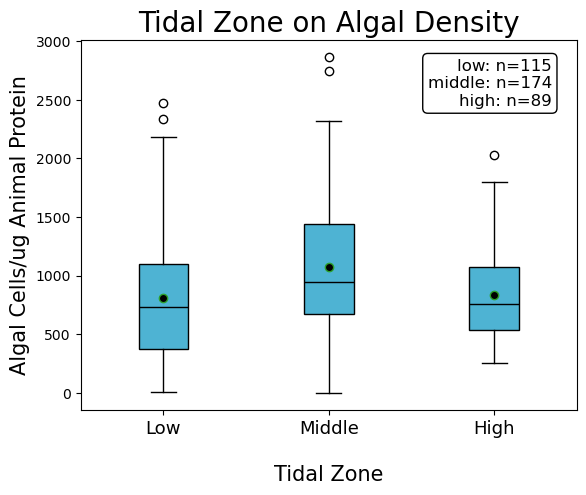

In [20]:
intertidal_box_plot(a_sola_algae_data, 'num_cells_per_ug_protein', yaxis='Algal Cells/ug Animal Protein', title='Tidal Zone on Algal Density', save_path='plots/algae_intertidal_box_plot.png', box_color='#4eb3d3')

Plot saved to plots/chlorophyll_intertidal_box_plot.png


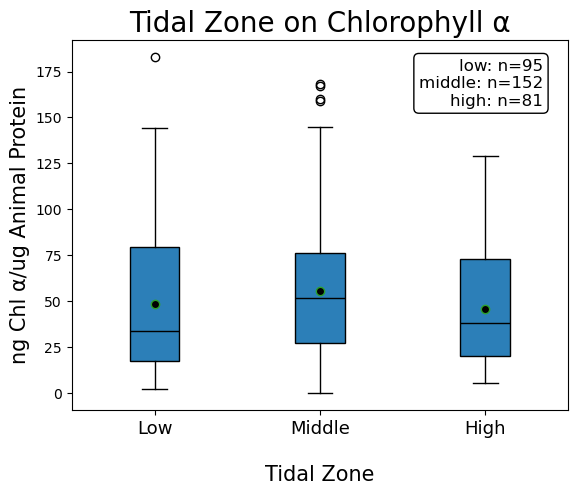

In [18]:
intertidal_box_plot(a_sola_chlorophyll_data, 'ng_chlorophyll_per_ug_protein', yaxis='ng Chl α/ug Animal Protein',title='Tidal Zone on Chlorophyll α', save_path='plots/chlorophyll_intertidal_box_plot.png', box_color='#2c7fb8')